# Synthesis and Capture

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from acadia.data import DataManager, Plotter, ArrayRecordGroup

import logging
logging.basicConfig(format='[%(asctime)s] %(threadName)s: %(message)s', datefmt='%m/%d/%Y %I:%M:%S %p', level=logging.INFO)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …
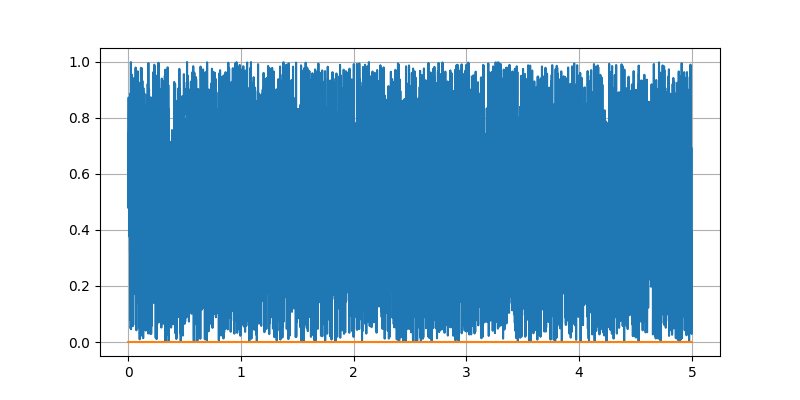

[10/04/2023 11:57:54 PM] MainThread: Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.2000000476837158, 'type': 'set_device_pixel_ratio'}


In [2]:
%matplotlib widget

# Make a function that will draw and update a plot
def plot(groups):
    # Just plot only the most recently received trace
    axis = groups["traces"].axis()*1e6
    trace = groups["traces"].data()[-1,:]
    
    # Prepare the background
    fig,ax = plt.subplots(figsize=(8,4))
    (line_re,) = ax.plot(axis, np.real(trace))
    (line_im,) = ax.plot(axis, np.imag(trace))
    ax.grid()
    
    while True:
        line_re.set_data(axis, np.real(trace))
        line_im.set_data(axis, np.imag(trace))
        fig.canvas.draw()
        yield
    
# Create and start a plotting client
plotter = Plotter(plot)
plotter.run(("192.168.2.69", 6672))

In [3]:
plotter.stop()